# ENGR 1451/2451 — LE02 Solutions
**Weekly Assignment 2 · 10 points**

Worked solutions for all four exercises. Read each written answer together with its table or plot. The explanations emphasize Boolean outlier masks, separate figures, and conclusions supported by the data.

## Setup

Keep `data/iris.csv` next to this notebook, as in the original assignment. Run the cells in order. Measurements in the Iris file are in centimeters.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

iris = pd.read_csv(Path("data/iris.csv"))
display(iris.head())

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## LE2-1. Shifting and scaling data (2 pts)

For `x = [4, 6, 8, 10, 12]`, compare the original data with `x + 7` and `3 * x`.

### A. Predict first (1 pt)

| Statistic | After adding 7 | After multiplying by 3 |
|---|---|---|
| Mean | Increases by 7 | Multiplied by 3 |
| Median | Increases by 7 | Multiplied by 3 |
| Sample standard deviation, $s$ | Unchanged | Multiplied by 3 |
| IQR | Unchanged | Multiplied by 3 |

**Reasoning:** Adding the same constant moves every observation equally, so the center changes but the distances between observations do not. Multiplying by 3 multiplies both the center and all distances by 3.

### B. Verify with Python (1 pt)

In [2]:
x = pd.Series([4, 6, 8, 10, 12], name="original")
shifted = x + 7
scaled = 3 * x

transformed = pd.DataFrame({
    "Original": x,
    "Shifted (+7)": shifted,
    "Scaled (×3)": scaled,
})

transformation_summary = pd.DataFrame({
    "Mean": transformed.mean(),
    "Median": transformed.median(),
    "s": transformed.std(ddof=1),
    "IQR": transformed.quantile(0.75) - transformed.quantile(0.25),
})
display(transformation_summary.round(3))

,Mean,Median,s,IQR
Original,8.0,8.0,3.162,4.0
Shifted (+7),15.0,15.0,3.162,4.0
Scaled (×3),24.0,24.0,9.487,12.0


**Answer:** The results agree with the predictions. Adding 7 changes the mean and median from 8 to 15, while $s$ remains about 3.162 and the IQR remains 4. Multiplying by 3 gives a mean and median of 24, $s$ of about 9.487, and an IQR of 12.

`ddof=1` requests the **sample** standard deviation. Round the displayed results, not the data used in calculations.

## LE2-2. Quartiles, IQR, and outliers (2 pts)

Use **all observations of `sepal.width`**, without separating the species. Find the quartiles, IQR, Tukey fences, and every observation outside the fences.

### Step 1. Calculate the fences

$$
\mathrm{IQR}=Q_3-Q_1,\qquad
\mathrm{lower\ fence}=Q_1-1.5\,\mathrm{IQR},\qquad
\mathrm{upper\ fence}=Q_3+1.5\,\mathrm{IQR}.
$$

The **lower** fence subtracts from $Q_1$; the **upper** fence adds to $Q_3$.

In [3]:
sepal_width = iris["sepal.width"]

q1 = sepal_width.quantile(0.25)
median = sepal_width.median()
q3 = sepal_width.quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

fence_summary = pd.DataFrame({
    "Q1": [q1],
    "Median": [median],
    "Q3": [q3],
    "IQR": [iqr],
    "Lower fence": [lower_fence],
    "Upper fence": [upper_fence],
}, index=["Sepal width (cm)"])
display(fence_summary.round(3))

,Q1,Median,Q3,IQR,Lower fence,Upper fence
Sepal width (cm),2.8,3.0,3.3,0.5,2.05,4.05


### Step 2. Compare → combine → select

An observation is outside the fences when it is **below the lower fence OR above the upper fence**. Each comparison produces a Series of `True`/`False` values; `|` combines them one observation at a time.

In [4]:
is_low = sepal_width < lower_fence
is_high = sepal_width > upper_fence
is_outlier = is_low | is_high

# Square brackets select every row for which the mask is True.
outliers = iris.loc[is_outlier]
display(outliers)

print(f"Flagged observations: {is_outlier.sum()}")
print(f"Low outliers: {is_low.sum()}; high outliers: {is_high.sum()}")

,sepal.length,sepal.width,petal.length,petal.width,variety
15,5.7,4.4,1.5,0.4,Setosa
32,5.2,4.1,1.5,0.1,Setosa
33,5.5,4.2,1.4,0.2,Setosa
60,5.0,2.0,3.5,1.0,Versicolor


Flagged observations: 4
Low outliers: 1; high outliers: 3


**Answer:** $Q_1=2.80$, median $=3.00$, $Q_3=3.30$, and IQR $=0.50$ cm. The fences are **2.05 cm** and **4.05 cm**. There are **4 flagged observations: 1 low** (2.0 cm) **and 3 high** (4.1, 4.2, and 4.4 cm).

The displayed index labels identify the observations in the original DataFrame. The code selects them by their measurements, not by typing row numbers. A flag identifies an unusual value under this rule; it does not prove a data-entry error or justify automatic removal.

### Why `|`, not `&` or `or`?

| Sepal width (cm) | Below 2.05? | Above 4.05? | Either condition (`|`)? |
|---|---|---|---|
| 2.0 | `True` | `False` | `True` |
| 3.0 | `False` | `False` | `False` |
| 4.4 | `False` | `True` | `True` |

The one-line equivalent is:

```python
is_outlier = (sepal_width < lower_fence) | (sepal_width > upper_fence)
```

**Outside → `|` (OR). Inside → `&` (AND).** For example, an inside-fence mask is `(sepal_width >= lower_fence) & (sepal_width <= upper_fence)`. Using `&` for the two outside conditions would require the same value to be below the lower fence and above the upper fence at once.

Use parentheses around each comparison. Python's `and`/`or` do not combine Boolean Series element by element. Use `iris.loc[is_outlier]` to select rows; `sepal_width(...)` would incorrectly try to call the Series as a function. Values exactly on a fence are **not** flagged.

## LE2-3. Visualizing a distribution and comparing groups (4 pts)

Use **`sepal.length`** throughout this exercise. Do not reuse the sepal-width fences from LE2-2.

### A. Histograms and bin choice (1.5 pts)

Plot the same measurements with **6 bins** and **18 bins**. Start a new figure for each histogram and give each its own labels and title.

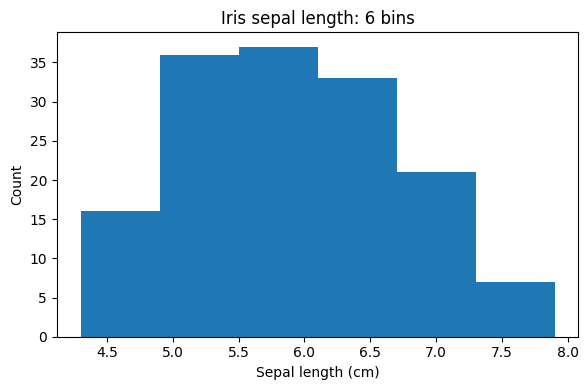

In [5]:
sepal_length = iris["sepal.length"]

# First figure: 6 bins.
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(sepal_length, bins=6)
ax.set(
    xlabel="Sepal length (cm)",
    ylabel="Count",
    title="Iris sepal length: 6 bins",
)
fig.tight_layout()
plt.show()

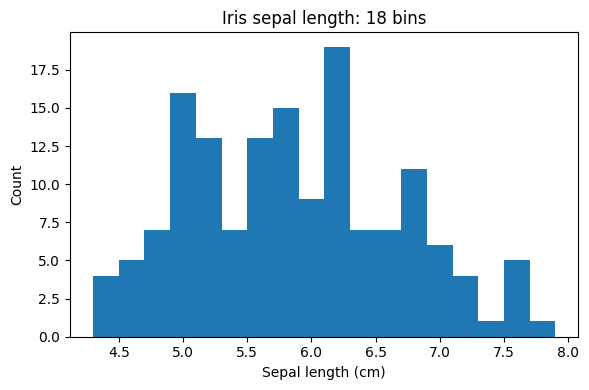

In [6]:
# Second figure: 18 bins, using exactly the same measurements.
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(sepal_length, bins=18)
ax.set(
    xlabel="Sepal length (cm)",
    ylabel="Count",
    title="Iris sepal length: 18 bins",
)
fig.tight_layout()
plt.show()

**Answer:** Both histograms cover approximately **4.3–7.9 cm**, with much of the data around **5–6.5 cm** and relatively few observations at the largest lengths. Using 18 bins produces narrower bars and a more irregular appearance; using 6 bins combines more observations in each bar and hides some detail. The observations and their numerical summaries have not changed.

**Plotting check:** `fig, ax = plt.subplots()` returns two objects: the figure and its plotting axes. Call plotting methods on `ax`, not on the returned pair. Write **`plt.show()`**, including the parentheses; `plt.show` alone does not call the function. The separate `plt.subplots()` calls above are what create separate figures.

**Interpretation check:** A sparse tail or a small bar is not automatically a Tukey outlier. For these pooled **sepal lengths**, $Q_1=5.10$ and $Q_3=6.40$, giving fences **3.15–8.35 cm**. All lengths are inside them. Do not infer distinct populations merely because one bin choice produces multiple local peaks.

### B. Grouped numerical summary (1 pt)

Use `groupby()` and `agg()` to calculate the count, median, sample standard deviation, minimum, and maximum of sepal length for each species.

In [7]:
summary_by_species = iris.groupby("variety")["sepal.length"].agg(
    ["count", "median", "std", "min", "max"]
)
display(summary_by_species.round(3))

,count,median,std,min,max
variety,,,,,
Setosa,50,5.0,0.352,4.3,5.8
Versicolor,50,5.9,0.516,4.9,7.0
Virginica,50,6.5,0.636,4.9,7.9


**Answer:** **Virginica** has both the largest median sepal length (**6.5 cm**) and the largest sample standard deviation (**about 0.636 cm**). Each species has 50 observations.

`groupby("variety")` separates the species, `["sepal.length"]` selects the measurement, and `agg(...)` computes the requested statistics. Here, pandas' `"std"` uses the sample standard deviation (`ddof=1`).

### C. Boxplot by species (1.5 pts)

Create a grouped boxplot and give two conclusions: one about center and one about spread or overlap.

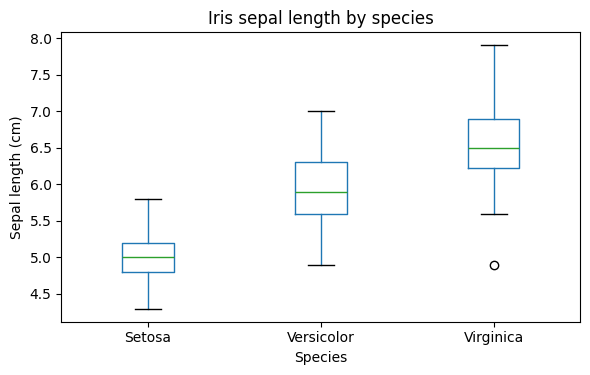

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
iris.boxplot(column="sepal.length", by="variety", ax=ax, grid=False)
ax.set(
    xlabel="Species",
    ylabel="Sepal length (cm)",
    title="Iris sepal length by species",
)
fig.suptitle("")  # Remove pandas' automatic extra title.
fig.tight_layout()
plt.show()

**Center:** Virginica has the largest median sepal length (6.5 cm), followed by Versicolor (5.9 cm) and Setosa (5.0 cm).

**Spread/overlap:** Setosa has a narrower middle 50% of lengths (IQR about 0.40 cm) than Versicolor and Virginica (both about 0.7 cm), while the observed lengths of Versicolor and Virginica overlap substantially.

**Read the correct measure of spread:** Box height represents **IQR, not $s$**. Versicolor's IQR is 0.700 cm and Virginica's is 0.675 cm, even though Virginica has the larger sample standard deviation.

**Why is there a point below the Virginica whisker?** The 4.9 cm Virginica observation is below its **within-species** lower fence (5.2125 cm). Grouped boxplots calculate separate fences for each species. This does not contradict the absence of outliers using the **pooled** sepal-length fences in part A. Whiskers end at the most extreme observations still within the fences, not necessarily at the fence values themselves.

## LE2-4. Similar summaries can hide different distributions (2 pts)

### A. Compare numerical summaries (0.75 pt)

Calculate the mean, median, and sample standard deviation for the supplied datasets A and B.

In [9]:
comparison = pd.DataFrame({
    "A": [1, 2, 3, 4, 5, 6, 7, 8, 9],
    "B": [0, 3, 4, 5, 5, 5, 6, 7, 10],
})
display(comparison)

comparison_summary = comparison.agg(["mean", "median", "std"])
display(comparison_summary.round(3))

,A,B
0,1,0
1,2,3
2,3,4
3,4,5
4,5,5
5,6,5
6,7,6
7,8,7
8,9,10


,A,B
mean,5.000,5.000
median,5.000,5.000
std,2.739,2.739


**Answer:** Both datasets have **mean = 5**, **median = 5**, and **sample standard deviation $s\approx2.739$**. These summaries agree exactly before rounding (apart from possible floating-point representation).

### B. Visualize the distributions (0.75 pt)

This solution chooses **histograms**. Use identical bin edges and axis limits so that A and B can be compared directly. Since the values are integers, use bins of width 1 centered on the integers; the edges are at half-integers.

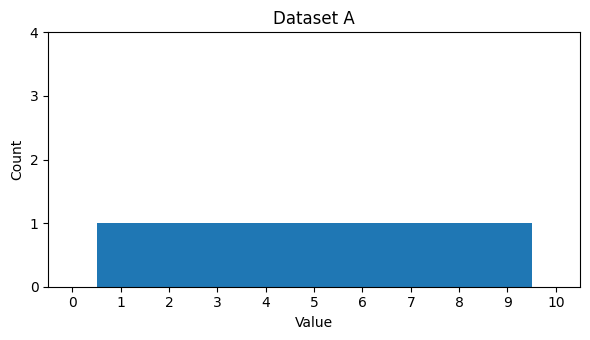

In [10]:
# Derive the shared plotting range from both datasets.
value_min = int(comparison.min().min())
value_max = int(comparison.max().max())
bin_width = 1
bin_edges = np.arange(
    value_min - bin_width / 2,
    value_max + bin_width,
    bin_width,
)

# Use the same count scale for both figures.
max_count = max(
    comparison["A"].value_counts().max(),
    comparison["B"].value_counts().max(),
)
count_limit = int(max_count) + 1

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(comparison["A"], bins=bin_edges)
ax.set(
    xlabel="Value",
    ylabel="Count",
    title="Dataset A",
    xlim=(bin_edges.min(), bin_edges.max()),
    ylim=(0, count_limit),
)
ax.set_xticks(range(value_min, value_max + 1))
ax.set_yticks(range(count_limit + 1))
fig.tight_layout()
plt.show()

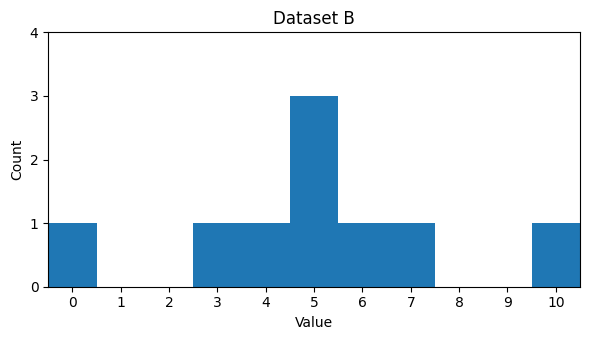

In [11]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(comparison["B"], bins=bin_edges)
ax.set(
    xlabel="Value",
    ylabel="Count",
    title="Dataset B",
    xlim=(bin_edges.min(), bin_edges.max()),
    ylim=(0, count_limit),
)
ax.set_xticks(range(value_min, value_max + 1))
ax.set_yticks(range(count_limit + 1))
fig.tight_layout()
plt.show()

### C. Interpret (0.5 pt)

**Model answer:** A has one observation at every integer from 1 to 9, whereas B is more concentrated at 5 and includes more distant endpoints at 0 and 10. Numerical summaries and plots should be used together because the same mean, median, and sample standard deviation can hide differences in concentration and tail structure.

**Check the dataset label and the raw values:** A contains every integer from 1 through 9; there is no missing interior integer that splits A into two groups. B is the dataset with three observations at 5 and empty bins at 1, 2, 8, and 9. Very narrow bins can create empty bars between regularly spaced observations, so a gap in one histogram does not, by itself, establish separate groups.

## Compact Python reference

| Task | Pattern |
|---|---|
| Select a column / select flagged rows | `df["column"]` / `df.loc[mask]` |
| Quartiles and sample spread | `s.quantile(0.25)`, `s.quantile(0.75)`, `s.std(ddof=1)` |
| Outside / inside two fences | <code>(s &lt; lower) &#124; (s &gt; upper)</code> / `(s >= lower) & (s <= upper)` |
| Summarize by group | `df.groupby("group")["value"].agg(["count", "median", "std"])` |
| Create a separate figure | `fig, ax = plt.subplots()` |
| Plot and label | `ax.hist(s, bins=6)`; `ax.set(xlabel="...", ylabel="...", title="...")` |
| Finish the figure | `fig.tight_layout()`; `plt.show()` |

**Before writing a conclusion:** Confirm the variable and group, identify the actual feature in the plot, and check it against the raw data or relevant summary. Distinguish a visual impression from a formal outlier flag.

<details>
<summary>Source and method notes</summary>

The questions and Iris observations are from Paul W. Leu's course repository, accessed September 21, 2026. The LE2-4 arrays are preserved exactly. Numerical answers and plots were computed from these data; the explanations are written for this solution key. No individual student's session record is reproduced.

```text
Assignment:
https://raw.githubusercontent.com/pleu/26f-engr1451-2451/main/1-assignments/LE02/LE02.ipynb
Iris data:
https://raw.githubusercontent.com/pleu/26f-engr1451-2451/main/1-assignments/LE02/data/iris.csv
pandas Boolean indexing:
https://pandas.pydata.org/docs/user_guide/indexing.html#boolean-indexing
Matplotlib figures and axes:
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
Matplotlib histograms:
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html
Matplotlib boxplots:
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html
```

Quartiles use pandas' default linear interpolation. All reported standard deviations are sample standard deviations. Boxplots use the default 1.5 × IQR rule.

</details>